# Data Understanding

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from warnings import filterwarnings
filterwarnings('ignore')

In [4]:
df = pd.read_csv('heart.csv')
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [9]:
df.select_dtypes(include=['object']).describe().T

,count,unique,top,freq
Sex,918,2,M,725
ChestPainType,918,4,ASY,496
RestingECG,918,3,Normal,552
ExerciseAngina,918,2,N,547
ST_Slope,918,3,Flat,460


# **Data Cleaning**
---

**Handling Duplicate Rows**

In [10]:
df.duplicated().sum()

0

**Handling Missing Data**

In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

**Handling Outliers**

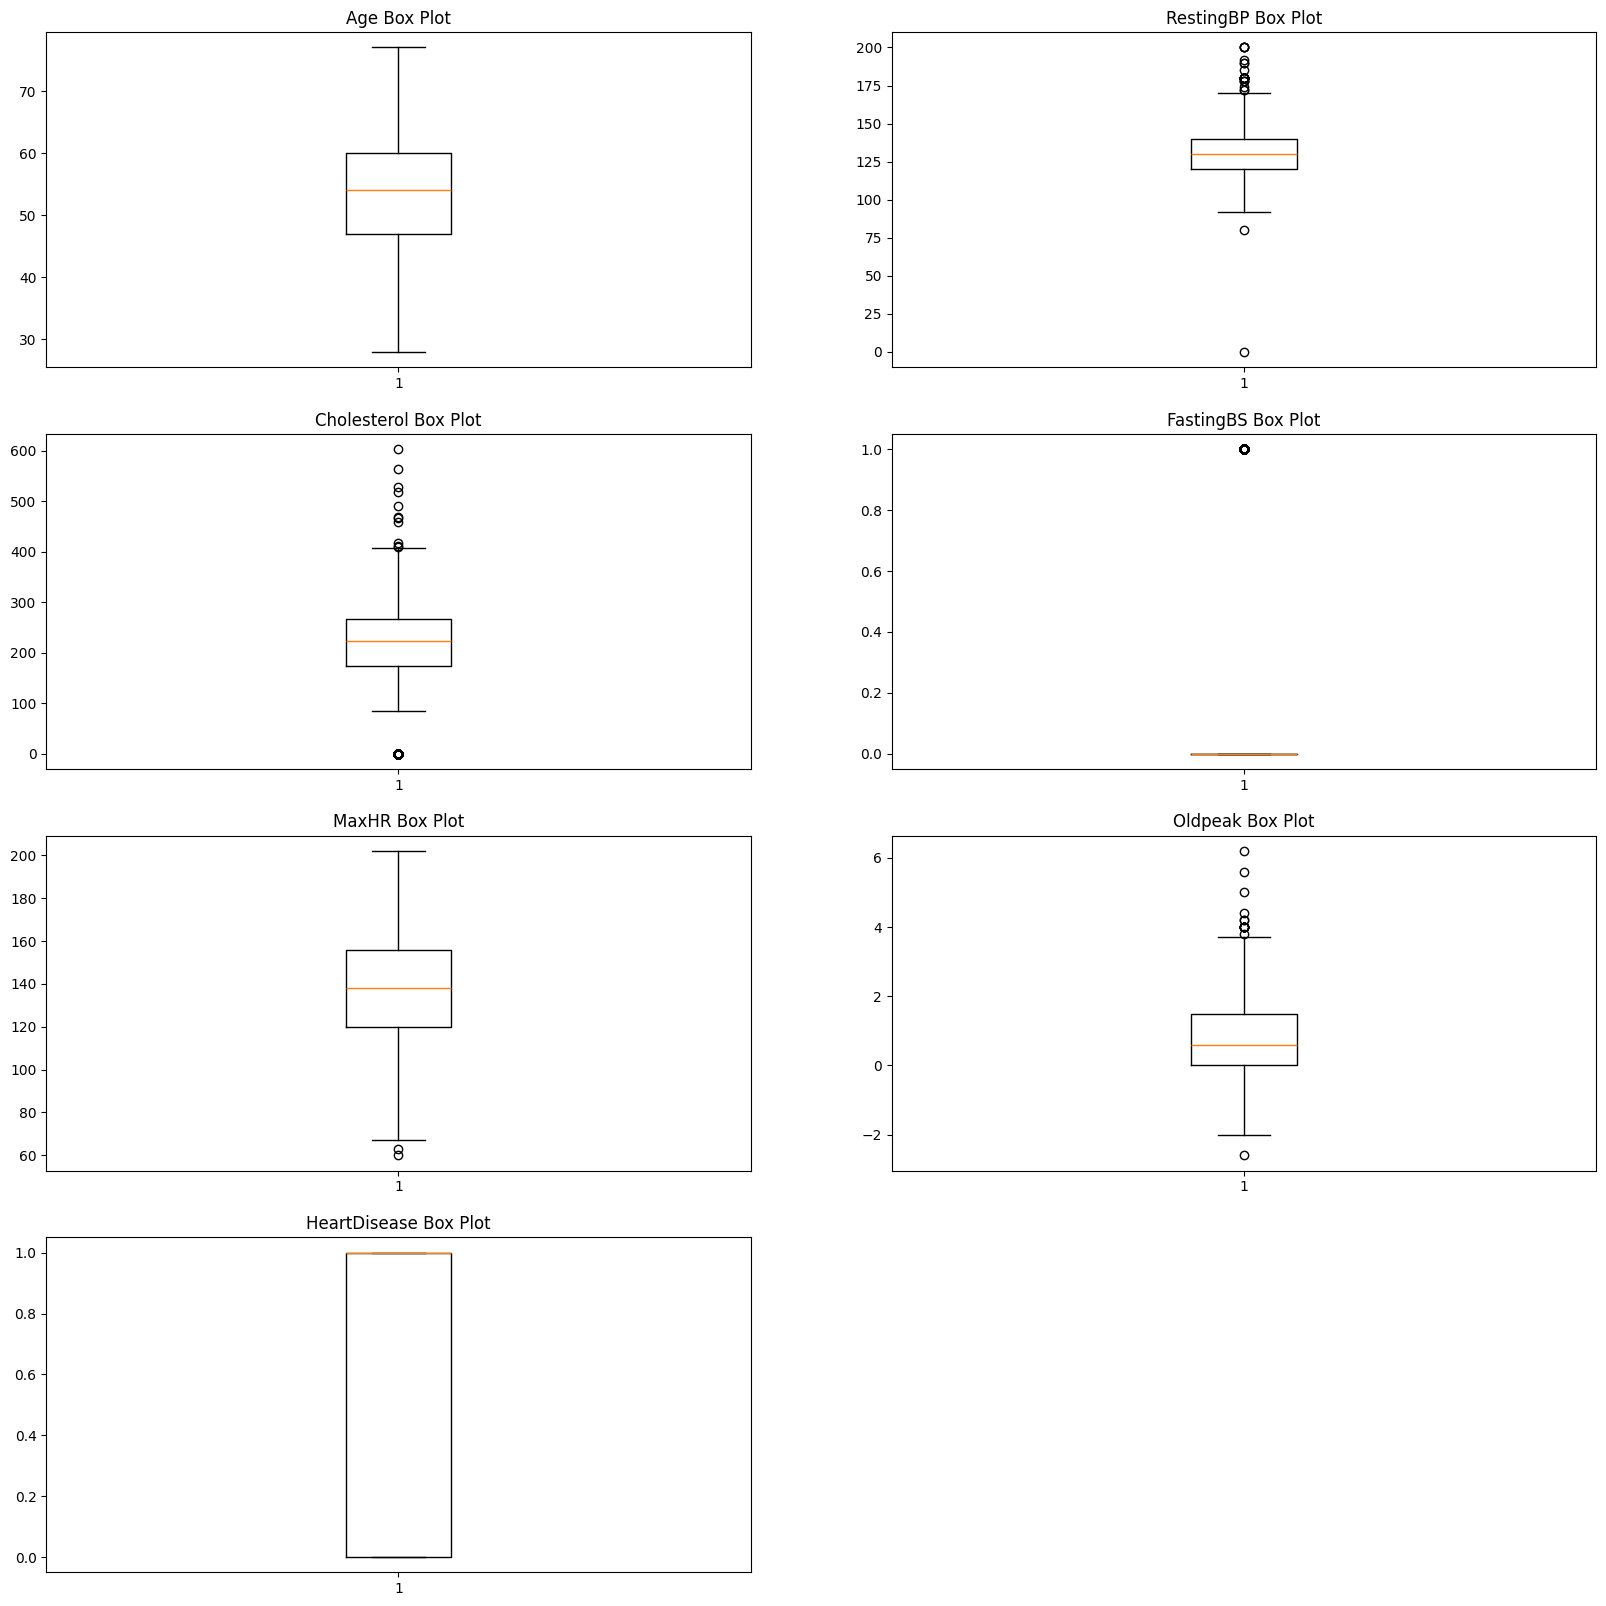

In [12]:
Numeric_columns = df.select_dtypes('number').columns
Numeric_columns
plt.figure(figsize=(20,20))
for i , col in enumerate(Numeric_columns):
    plt.subplot(4,2,i+1)
    plt.boxplot(df[col])
    plt.title(f'{col} Box Plot')
plt.show() 

In [13]:

for col in Numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Upper_Fennse = Q3 + (1.5*IQR)
    lower_fennse = Q1 - (1.5*IQR)
    Low_Outlier = df[df[col] < lower_fennse][col].values
    Up_Outlier = df[df[col] > Upper_Fennse][col].values
    df[col].replace(Low_Outlier , lower_fennse , inplace=True)
    df[col].replace(Up_Outlier , Upper_Fennse , inplace=True)


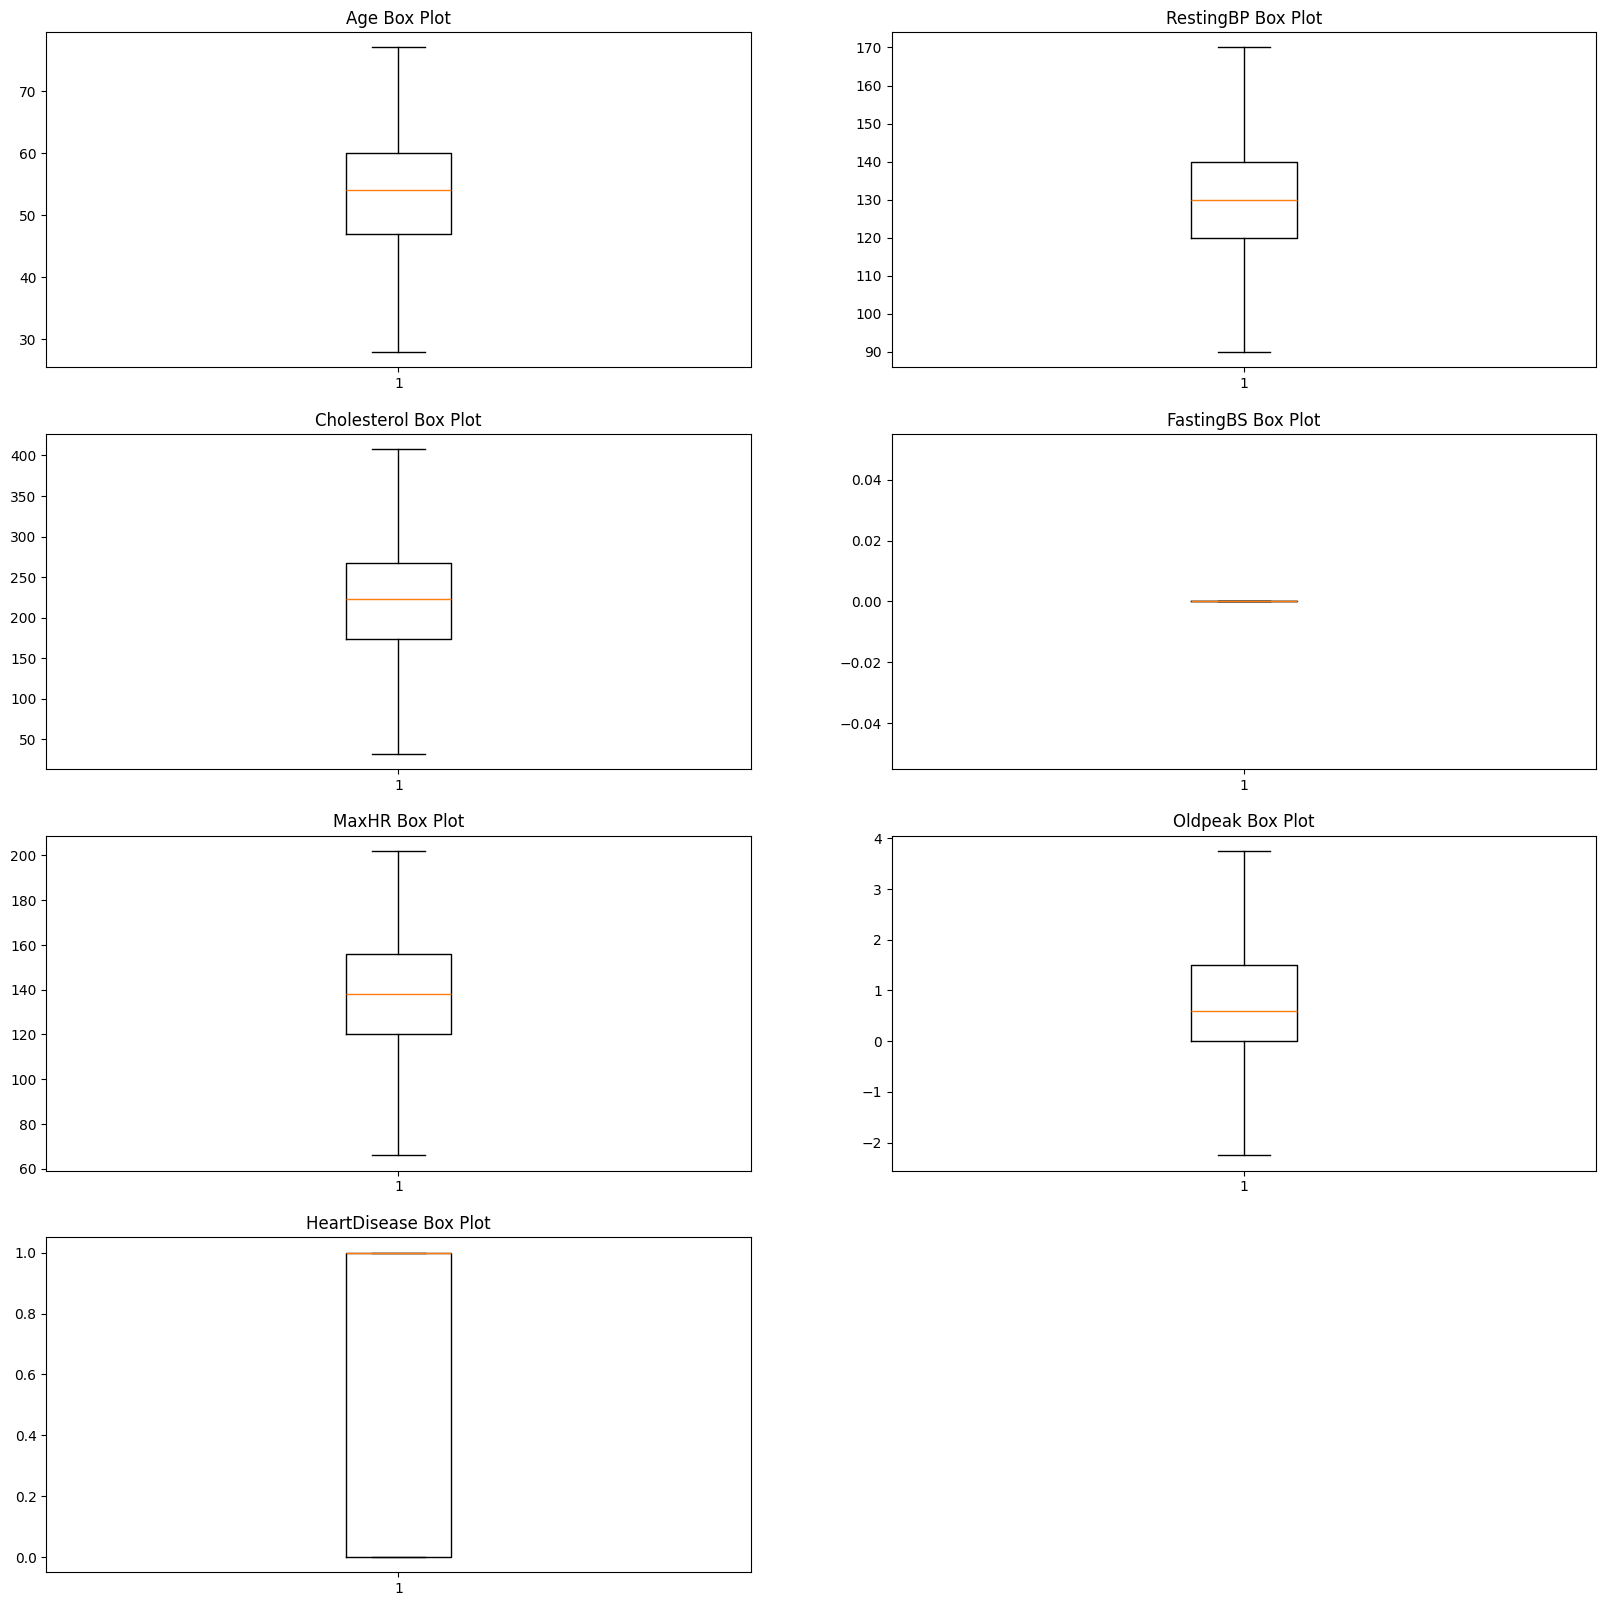

In [14]:
Numeric_columns = df.select_dtypes('number').columns
Numeric_columns
plt.figure(figsize=(20,20))
for i , col in enumerate(Numeric_columns):
    plt.subplot(4,2,i+1)
    plt.boxplot(df[col])
    plt.title(f'{col} Box Plot')
plt.show() 

# **EDA**
---

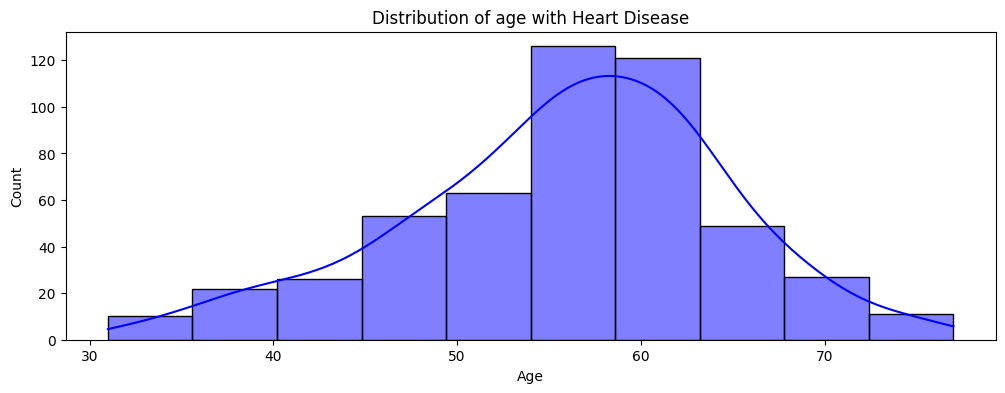

In [15]:
plt.figure(figsize=(12,4))
sns.histplot(df['Age'][df['HeartDisease']==1],bins=10,color='blue',kde=True)
plt.title('Distribution of age with Heart Disease')
plt.show()

In [16]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [17]:
df["HeartDisease"].value_counts()*100/len(df)

HeartDisease
1    55.337691
0    44.662309
Name: count, dtype: float64

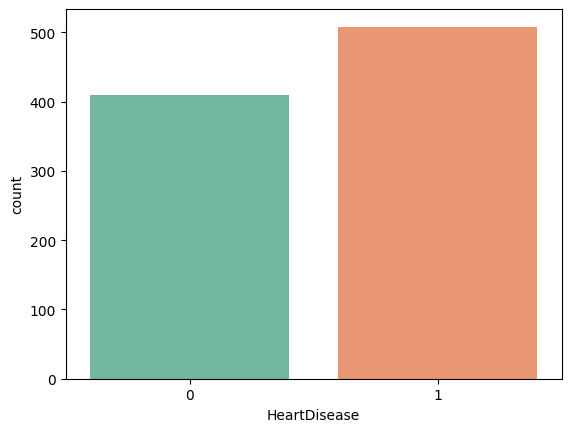

In [18]:
sns.countplot(x='HeartDisease', data=df, palette='Set2')
plt.show()

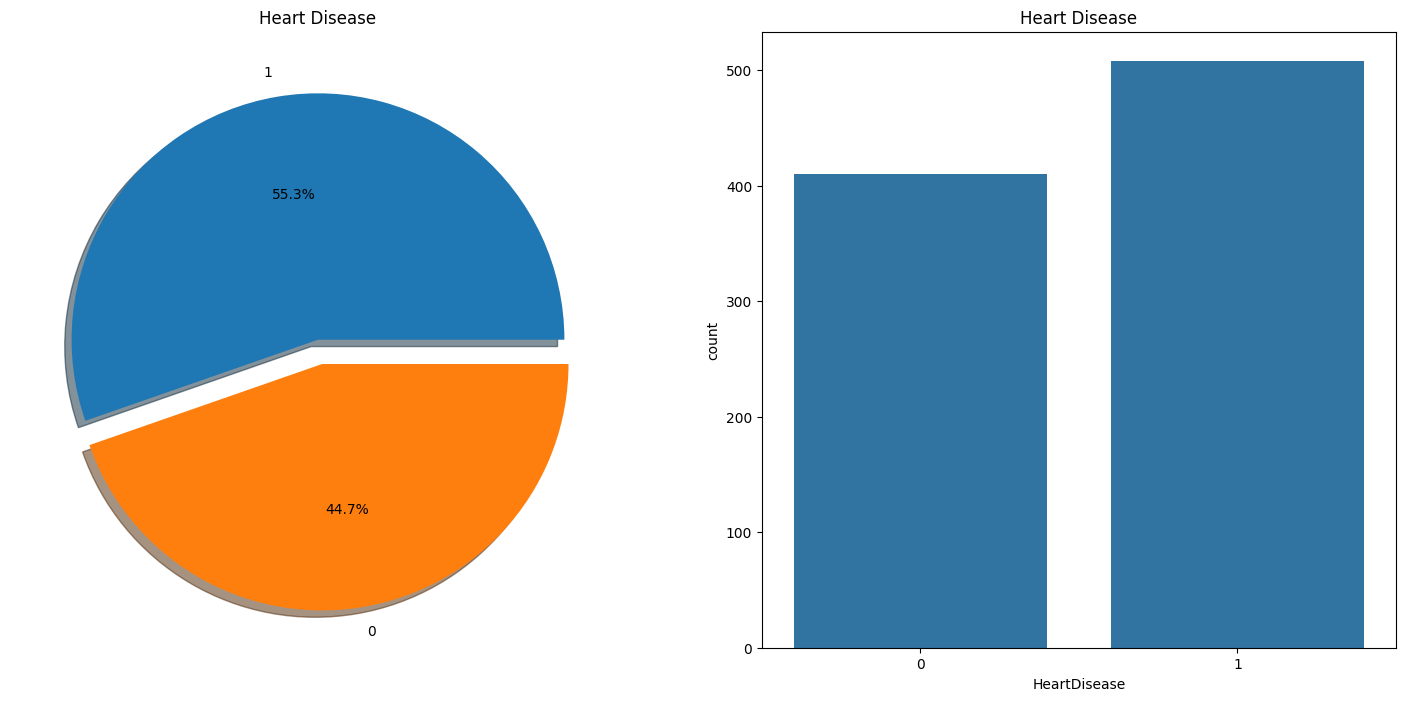

In [19]:
# The distribution of the outcome variable in the data was examined and visualized.
f,ax=plt.subplots(1,2,figsize=(18,8))
df['HeartDisease'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Heart Disease')
ax[0].set_ylabel('')
sns.countplot(x='HeartDisease',data=df,ax=ax[1])
ax[1].set_title('Heart Disease')
plt.show()

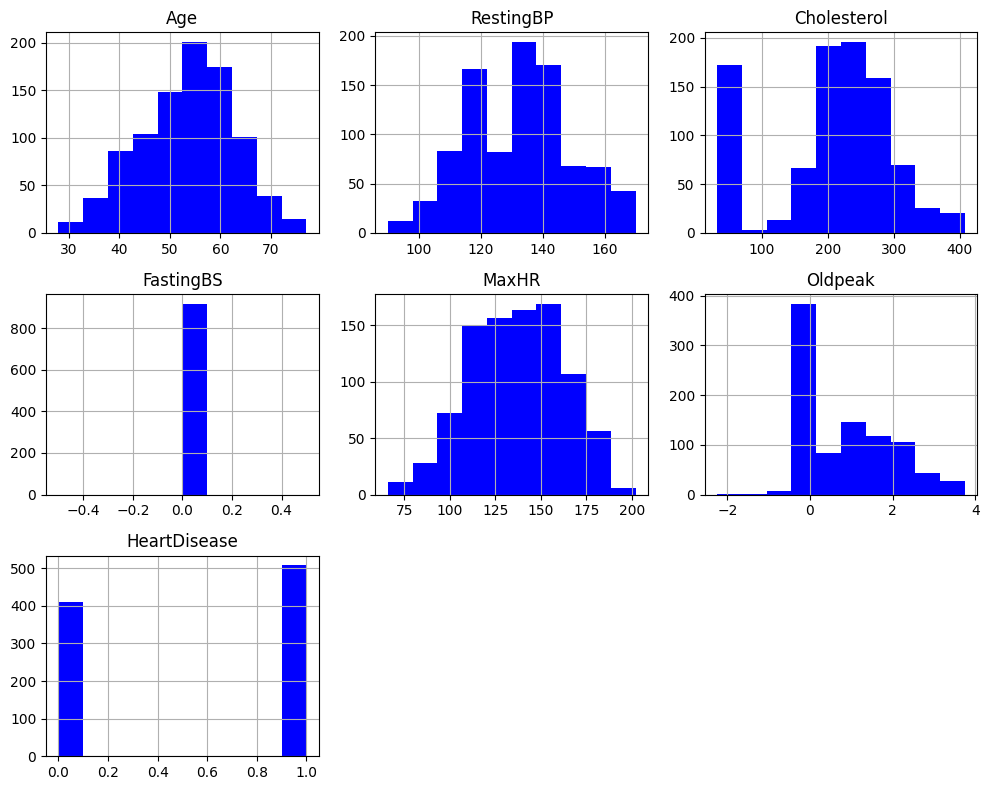

In [20]:
numerical_data = df.select_dtypes(include='number')
numerical_data.hist(figsize=(10, 8),color = 'b')
plt.tight_layout()
plt.show()

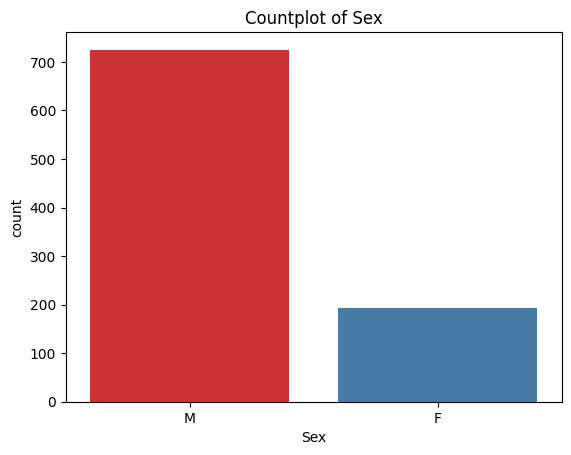

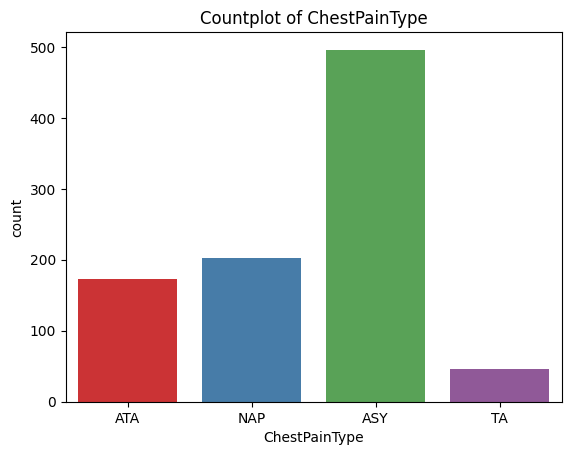

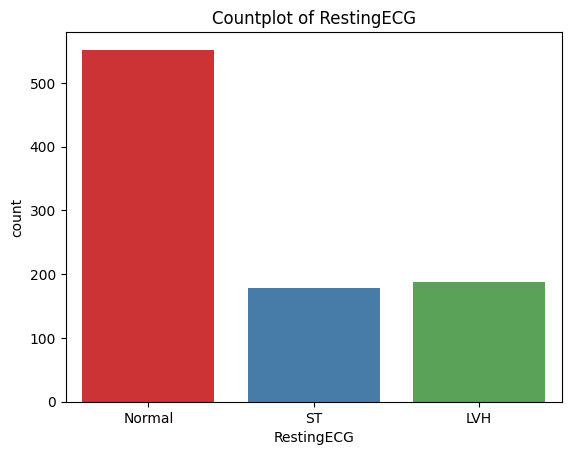

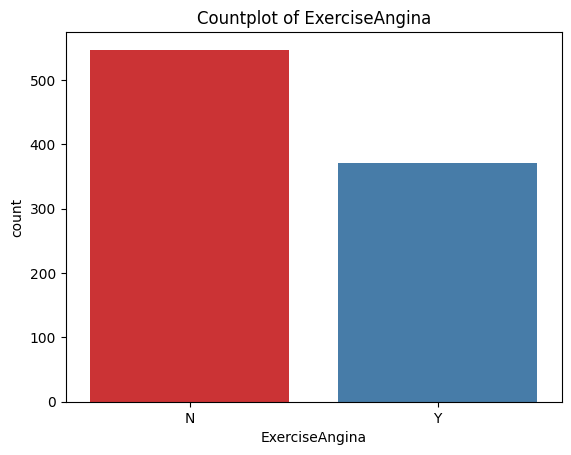

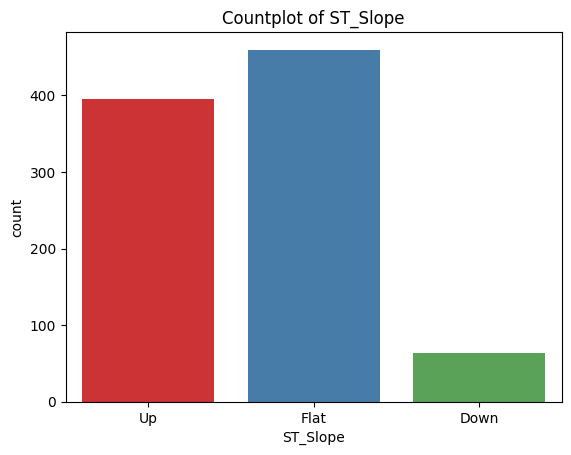

In [21]:
categorical_data = df.select_dtypes(include='object')
for column in categorical_data.columns:
    sns.countplot(data=categorical_data, x=column, palette="Set1")
    plt.title(f"Countplot of {column}")
    plt.show()

# **Data Preprocessing**
---

***Encoding Categorical Columns***

In [22]:
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['ChestPainType']=le.fit_transform(df['ChestPainType'])
df['RestingECG']=le.fit_transform(df['RestingECG'])
df['ExerciseAngina']=le.fit_transform(df['ExerciseAngina'])
df['ST_Slope']=le.fit_transform(df['ST_Slope'])

In [23]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289.0,0,1,172,0,0.0,2,0
1,49,0,2,160,180.0,0,1,156,0,1.0,1,1
2,37,1,1,130,283.0,0,2,98,0,0.0,2,0
3,48,0,0,138,214.0,0,1,108,1,1.5,1,1
4,54,1,2,150,195.0,0,1,122,0,0.0,2,0


***Normalizatio of Data***

In [24]:
from sklearn.preprocessing import MinMaxScaler
numCol = df.select_dtypes('number').columns
scaler = MinMaxScaler()
scaler.fit(df[numCol])
df[numCol] = scaler.transform(df[numCol])
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.244898,1.0,0.333333,0.625,0.683667,0.0,0.5,0.779412,0.0,0.375000,1.0,0.0
1,0.428571,0.0,0.666667,0.875,0.393000,0.0,0.5,0.661765,0.0,0.541667,0.5,1.0
2,0.183673,1.0,0.333333,0.500,0.667667,0.0,1.0,0.235294,0.0,0.375000,1.0,0.0
3,0.408163,0.0,0.000000,0.600,0.483667,0.0,0.5,0.308824,1.0,0.625000,0.5,1.0
4,0.530612,1.0,0.666667,0.750,0.433000,0.0,0.5,0.411765,0.0,0.375000,1.0,0.0


***Spliting Data***

In [25]:
x=df.drop(columns=['HeartDisease'])
y=df['HeartDisease']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.10,random_state=101,stratify=y)

# **Traditional models**
---

In [26]:
def evaluate_model(model,pred):
    print(f'Accuracy Train Score : {model.score(x_train,y_train)}\n')
    print(f'Accuracy Test Score : {model.score(x_test,y_test)}\n')
    print(f'Classification Report: \n{classification_report(y_test,pred)}\n')
    cm=confusion_matrix(pred,y_test)
    sns.heatmap(cm,annot=True,fmt='d')
    plt.show()

***Logistic Regression***

In [27]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [28]:
y_pred_lr=lr.predict(x_test)

Accuracy Train Score : 0.8450363196125908

Accuracy Test Score : 0.9130434782608695

Classification Report: 
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        41
         1.0       0.92      0.92      0.92        51

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.91      0.91      0.91        92




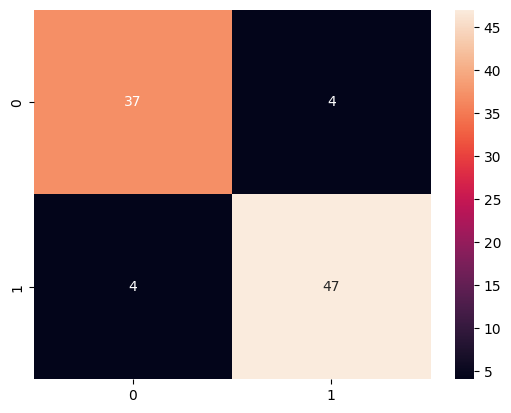

In [29]:
evaluate_model(lr,y_pred_lr)

***DT***

In [30]:
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [31]:
y_pred_dt=dt.predict(x_test)

Accuracy Train Score : 1.0

Accuracy Test Score : 0.8695652173913043

Classification Report: 
              precision    recall  f1-score   support

         0.0       0.89      0.80      0.85        41
         1.0       0.85      0.92      0.89        51

    accuracy                           0.87        92
   macro avg       0.87      0.86      0.87        92
weighted avg       0.87      0.87      0.87        92




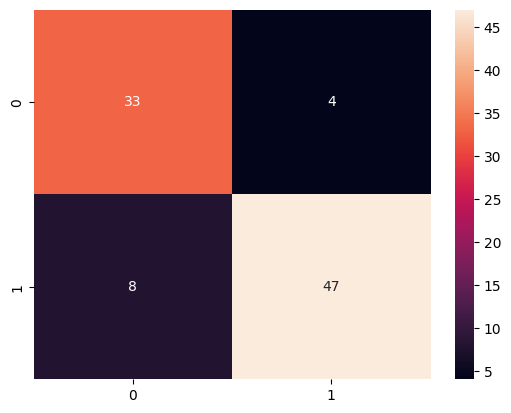

In [32]:
evaluate_model(dt,y_pred_dt)

***Random Forest***

In [33]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [34]:
y_pred_rf=rf.predict(x_test)

Accuracy Train Score : 1.0

Accuracy Test Score : 0.9456521739130435

Classification Report: 
              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94        41
         1.0       0.96      0.94      0.95        51

    accuracy                           0.95        92
   macro avg       0.94      0.95      0.95        92
weighted avg       0.95      0.95      0.95        92




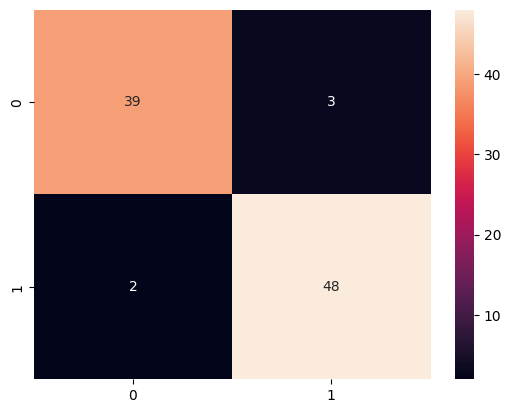

In [35]:
evaluate_model(rf,y_pred_rf)

In [36]:
# Save the model again with the current scikit-learn version
import joblib
joblib.dump(rf, "RF.pkl")
print("Model saved successfully!")

Model saved successfully!
